<a href="https://colab.research.google.com/github/chadlomas2011-blip/Customer-Churn-AI-Analytics/blob/main/Colab_SQL_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sqlite3; conn = sqlite3.connect(':memory:'); cursor = conn.cursor(); cursor.execute('CREATE TABLE sales_data (id INTEGER PRIMARY KEY, product TEXT, revenue REAL, region TEXT)'); data = [('Enterprise Plan', 1200.00, 'North America'), ('Pro Plan', 150.00, 'Europe'), ('Enterprise Plan', 2400.00, 'Asia-Pacific'), ('Starter Plan', 49.00, 'North America'), ('Pro Plan', 300.00, 'North America')]; cursor.executemany('INSERT INTO sales_data (product, revenue, region) VALUES (?, ?, ?)', data); conn.commit(); cursor.execute('SELECT region, SUM(revenue) FROM sales_data GROUP BY region'); results = cursor.fetchall(); print("📊 TOTAL REVENUE BY REGION"); print("=" * 35); print("\n".join([f"{region:<15} | ${total:>7.2f}  {'█' * int(total / 100)}" for region, total in results])); print("=" * 35)


📊 TOTAL REVENUE BY REGION
Asia-Pacific    | $2400.00  ████████████████████████
Europe          | $ 150.00  █
North America   | $1549.00  ███████████████


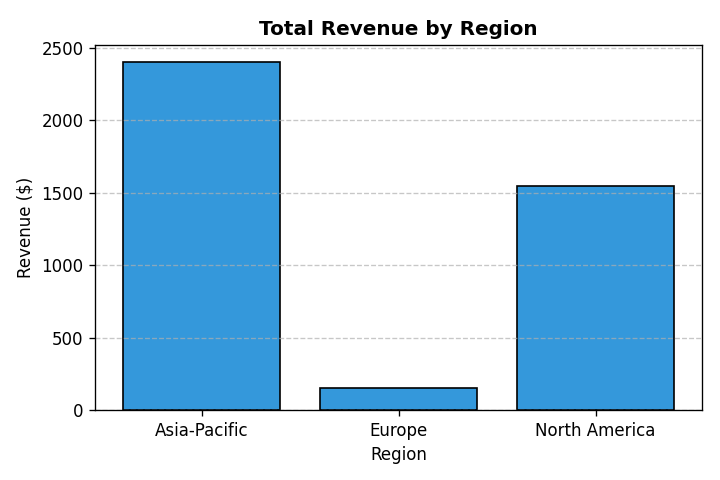

In [3]:
import sqlite3, matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt; conn = sqlite3.connect(':memory:'); cursor = conn.cursor(); cursor.execute('CREATE TABLE sales_data (id INTEGER PRIMARY KEY, product TEXT, revenue REAL, region TEXT)'); cursor.executemany('INSERT INTO sales_data (product, revenue, region) VALUES (?, ?, ?)', [('Enterprise Plan', 1200.00, 'North America'), ('Pro Plan', 150.00, 'Europe'), ('Enterprise Plan', 2400.00, 'Asia-Pacific'), ('Starter Plan', 49.00, 'North America'), ('Pro Plan', 300.00, 'North America')]); conn.commit(); cursor.execute('SELECT region, SUM(revenue) FROM sales_data GROUP BY region'); results = cursor.fetchall(); regions, revenues = [r[0] for r in results], [r[1] for r in results]; plt.figure(figsize=(6, 4)); plt.bar(regions, revenues, color='#3498db', edgecolor='black'); plt.title('Total Revenue by Region', fontweight='bold'); plt.xlabel('Region'); plt.ylabel('Revenue ($)'); plt.grid(axis='y', linestyle='--', alpha=0.7); plt.tight_layout(); plt.savefig('revenue_chart.png', dpi=120); from IPython.display import Image, display; display(Image('revenue_chart.png'))


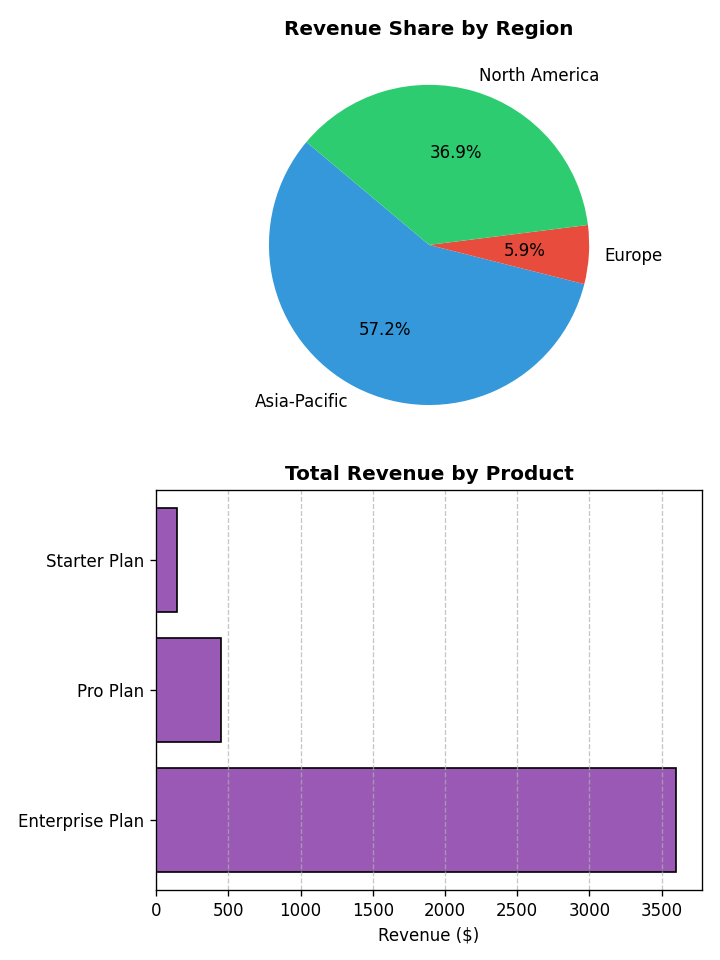

In [4]:
import sqlite3, matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt; conn = sqlite3.connect(':memory:'); cursor = conn.cursor(); cursor.execute('CREATE TABLE sales_data (id INTEGER PRIMARY KEY, product TEXT, revenue REAL, region TEXT)'); cursor.executemany('INSERT INTO sales_data (product, revenue, region) VALUES (?, ?, ?)', [('Enterprise Plan', 1200.00, 'North America'), ('Pro Plan', 150.00, 'Europe'), ('Enterprise Plan', 2400.00, 'Asia-Pacific'), ('Starter Plan', 49.00, 'North America'), ('Pro Plan', 300.00, 'North America'), ('Starter Plan', 99.00, 'Europe')]); conn.commit(); cursor.execute('SELECT region, SUM(revenue) FROM sales_data GROUP BY region'); r_data = cursor.fetchall(); regions, r_rev = [r[0] for r in r_data], [r[1] for r in r_data]; cursor.execute('SELECT product, SUM(revenue) FROM sales_data GROUP BY product'); p_data = cursor.fetchall(); products, p_rev = [p[0] for p in p_data], [p[1] for p in p_data]; fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8)); ax1.pie(r_rev, labels=regions, autopct='%1.1f%%', startangle=140, colors=['#3498db', '#e74c3c', '#2ecc71']); ax1.set_title('Revenue Share by Region', fontweight='bold'); ax2.barh(products, p_rev, color='#9b59b6', edgecolor='black'); ax2.set_title('Total Revenue by Product', fontweight='bold'); ax2.set_xlabel('Revenue ($)'); ax2.grid(axis='x', linestyle='--', alpha=0.7); plt.tight_layout(); plt.savefig('dashboard_stacked.png', dpi=120); from IPython.display import Image, display; display(Image('dashboard_stacked.png'))


In [2]:
import sqlite3, pandas as pd, matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt; from IPython.display import Image, display; conn = sqlite3.connect(':memory:'); url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'; df_remote = pd.read_csv(url); df_remote.to_sql('restaurant_sales', conn, if_exists='replace', index=False); print("✅ Web Dataset Loaded Into SQLite!"); print("Columns:", list(df_remote.columns)); print("\n📊 First 3 Rows:\n", pd.read_sql_query('SELECT * FROM restaurant_sales LIMIT 3', conn))


✅ Web Dataset Loaded Into SQLite!
Columns: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

📊 First 3 Rows:
    total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3


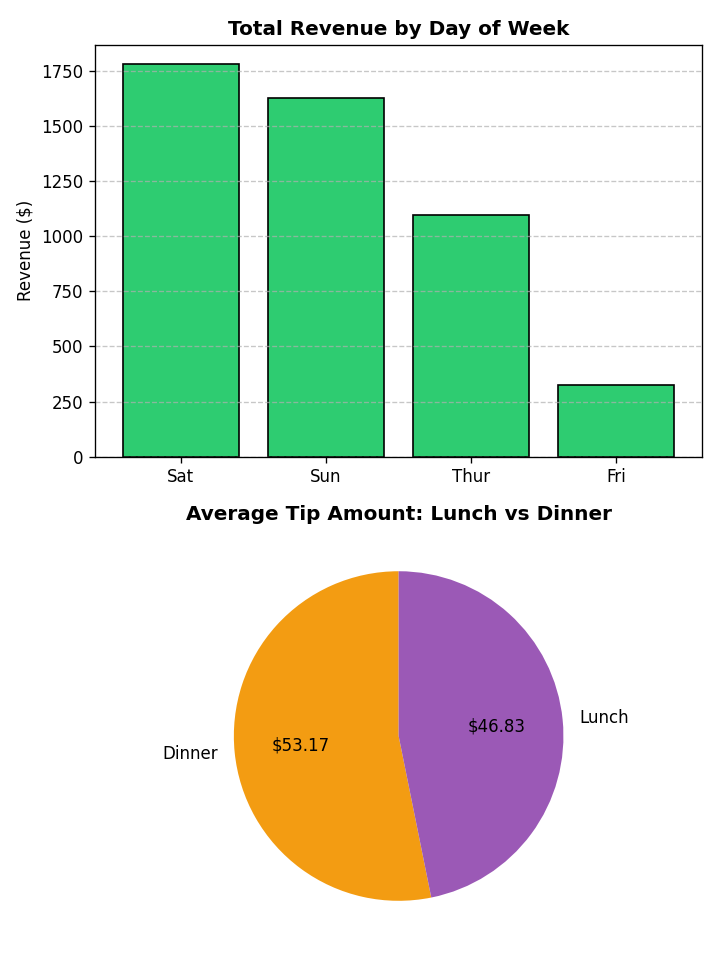

In [3]:
import sqlite3, pandas as pd, matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt; from IPython.display import Image, display; plt.close('all'); day_df = pd.read_sql_query("SELECT day, ROUND(SUM(total_bill), 2) AS total_revenue FROM restaurant_sales GROUP BY day ORDER BY total_revenue DESC", conn); time_df = pd.read_sql_query("SELECT time, ROUND(AVG(tip), 2) AS avg_tip FROM restaurant_sales GROUP BY time", conn); fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8)); ax1.bar(day_df['day'], day_df['total_revenue'], color='#2ecc71', edgecolor='black'); ax1.set_title('Total Revenue by Day of Week', fontweight='bold'); ax1.set_ylabel('Revenue ($)'); ax1.grid(axis='y', linestyle='--', alpha=0.7); ax2.pie(time_df['avg_tip'], labels=time_df['time'], autopct='$%1.2f', startangle=90, colors=['#f39c12', '#9b59b6']); ax2.set_title('Average Tip Amount: Lunch vs Dinner', fontweight='bold'); plt.tight_layout(); plt.savefig('restaurant_dashboard.png', dpi=120); display(Image('restaurant_dashboard.png'))


❓ Question: 'What is the best tipping day?'
🔍 Executed SQL: SELECT day, ROUND(AVG(tip), 2) AS avg_tip FROM restaurant_sales GROUP BY day ORDER BY avg_tip DESC



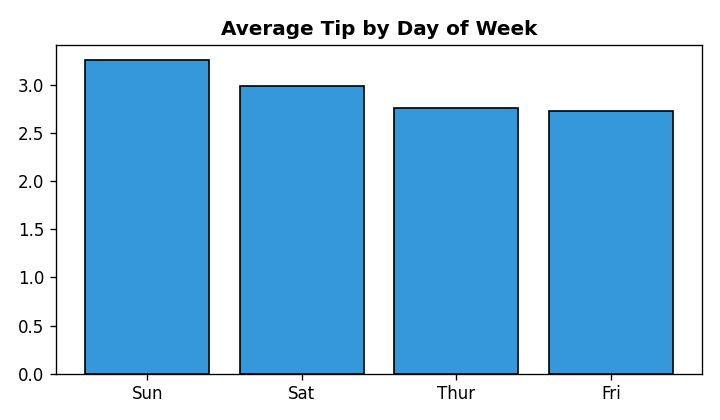

In [5]:
import sqlite3, pandas as pd, matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt; from IPython.display import Image, display; plt.close('all');

def ask_sales_ai(question): q = question.lower(); plt.close('all'); sql, title, x_col, y_col, kind = ("SELECT day, ROUND(AVG(tip), 2) AS avg_tip FROM restaurant_sales GROUP BY day ORDER BY avg_tip DESC", "Average Tip by Day of Week", "day", "avg_tip", "bar") if 'tip' in q and ('day' in q or 'best' in q) else (("SELECT size, ROUND(SUM(total_bill), 2) AS total_revenue FROM restaurant_sales GROUP BY size ORDER BY size", "Total Revenue by Party Size", "size", "total_revenue", "line") if 'party' in q or 'size' in q else (("SELECT time, ROUND(SUM(total_bill), 2) AS total_revenue FROM restaurant_sales GROUP BY time", "Revenue: Lunch vs Dinner", "time", "total_revenue", "pie") if 'time' in q or 'lunch' in q or 'dinner' in q else ("SELECT day, ROUND(SUM(total_bill), 2) AS total_revenue FROM restaurant_sales GROUP BY day ORDER BY total_revenue DESC", "Total Revenue by Day", "day", "total_revenue", "bar"))); df = pd.read_sql_query(sql, conn); print(f"❓ Question: '{question}'\n🔍 Executed SQL: {sql}\n"); fig, ax = plt.subplots(figsize=(6, 3.5)); (ax.bar(df[x_col].astype(str), df[y_col], color='#3498db', edgecolor='black') if kind == "bar" else (ax.plot(df[x_col].astype(str), df[y_col], marker='o', color='#e74c3c', linewidth=2) if kind == "line" else ax.pie(df[y_col], labels=df[x_col], autopct='%1.1f%%', colors=['#2ecc71', '#9b59b6']))); ax.set_title(title, fontweight='bold'); plt.tight_layout(); plt.savefig('nl_chart.png', dpi=120); display(Image('nl_chart.png'))

ask_sales_ai('What is the best tipping day?')
